In [1]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)
library(nationalparkcolors)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”


bedtools intersect -a MVP.NAFLD.TRANS.MVP.2021.credset.hg38.bed -b /nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/celltype.peaks/Hepatocytes_union.peaks -wa -wb -loj > MVP.NAFLD.TRANS.MVP.2021.credset.hg38.Hepatocyte.cREs.bed
bedtools intersect -a MVP.NAFLD.TRANS.MVP.2021.credset.hg38.bed -b /nfs/lab/tscc/welison/FNIH.Liver/peak.classifications/celltype/Liver_UnionPeak_Hepatocytes_annotate.bed -wa -wb -loj > MVP.NAFLD.TRANS.MVP.2021.credset.hg38.Hepatocyte.cREs.states.bed

In [2]:
Hep.cREs.fm <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/GWAS/MVP.NAFLD.TRANS.MVP.2021.credset.hg38.Hepatocyte.cREs.bed')

dim(Hep.cREs.fm)
head(Hep.cREs.fm)

[1] 1084   19

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1,220796685,220796686,rs2642438,1:220796686:A:G,6.65e-24,-0.075,rs2642438,0.9686,chr1,220796531,220796831,300,19563.000000,220796681,14342,13.6506,14339,Hepatocytes_peak_22237
2,chr2,113083452,113083453,rs6734238,2:113083453:G:A,4.94e-19,-0.057,rs6734238,0.9904,.,-1,-1,.,.,.,.,.,.,.
3,chr6,71185548,71185549,rs138033684,6:71185549:G:T,1.42e-09,0.677,rs138033684,0.9631,.,-1,-1,.,.,.,.,.,.,.
4,chr8,125495065,125495066,rs2980888,8:125495066:T:C,4.21e-72,0.130,rs2980888,0.9995,.,-1,-1,.,.,.,.,.,.,.
5,chr8,10713980,10713981,rs4484649,8:10713981:C:A,1.38e-11,0.045,rs4484649,0.9851,chr8,10713844,10714144,300,13686.000000,10713994,8908.04,11.1053,8905.29,Hepatocytes_peak_236239
6,chr8,9326085,9326086,rs4841132,8:9326086:A:G,6.62e-32,0.123,rs4841132,0.9879,chr8,9325934,9326177,244,208.000000,9326031,15.3179,1.83189,13.7066,Endothelial_peak_150594


In [3]:
Hep.cREs.states.fm <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/GWAS/MVP.NAFLD.TRANS.MVP.2021.credset.hg38.Hepatocyte.cREs.states.bed')

dim(Hep.cREs.states.fm)
head(Hep.cREs.states.fm)

[1] 1084   13

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>
1,chr1,220796685,220796686,rs2642438,1:220796686:A:G,6.65e-24,-0.075,rs2642438,0.9686,chr1,220796531,220796831,E5
2,chr2,113083452,113083453,rs6734238,2:113083453:G:A,4.94e-19,-0.057,rs6734238,0.9904,chr2,113083364,113083664,E5
3,chr6,71185548,71185549,rs138033684,6:71185549:G:T,1.42e-09,0.677,rs138033684,0.9631,.,-1,-1,.
4,chr8,125495065,125495066,rs2980888,8:125495066:T:C,4.21e-72,0.130,rs2980888,0.9995,.,-1,-1,.
5,chr8,10713980,10713981,rs4484649,8:10713981:C:A,1.38e-11,0.045,rs4484649,0.9851,chr8,10713844,10714144,E5
6,chr8,9326085,9326086,rs4841132,8:9326086:A:G,6.62e-32,0.123,rs4841132,0.9879,chr8,9325934,9326177,E5


In [4]:
Hep.cREs.states <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/GWAS/MVP.NAFLD.TRANS.MVP.2021.credset.hg38.Hepatocyte.active.bed')

dim(Hep.cREs.states)
head(Hep.cREs.states)

[1] 1084   13

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>
1,chr1,220796685,220796686,rs2642438,1:220796686:A:G,6.65e-24,-0.075,rs2642438,0.9686,chr1,220795800,220797600,E5
2,chr2,113083452,113083453,rs6734238,2:113083453:G:A,4.94e-19,-0.057,rs6734238,0.9904,chr2,113083400,113090400,E5
3,chr6,71185548,71185549,rs138033684,6:71185549:G:T,1.42e-09,0.677,rs138033684,0.9631,chr6,71185200,71190800,E2
4,chr8,125495065,125495066,rs2980888,8:125495066:T:C,4.21e-72,0.130,rs2980888,0.9995,chr8,125492600,125521400,E5
5,chr8,10713980,10713981,rs4484649,8:10713981:C:A,1.38e-11,0.045,rs4484649,0.9851,chr8,10712600,10716800,E5
6,chr8,9326085,9326086,rs4841132,8:9326086:A:G,6.62e-32,0.123,rs4841132,0.9879,chr8,9307200,9343400,E5


In [5]:
#Hep.cREs.states.active <- filter(Hep.cREs.states.fm, V13=='E5')
Hep.cREs.states.active <- filter(Hep.cREs.states, V13=='E5')

dim(Hep.cREs.states.active)
head(Hep.cREs.states.active)

[1] 397  13

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>
1,chr1,220796685,220796686,rs2642438,1:220796686:A:G,6.65e-24,-0.075,rs2642438,0.9686,chr1,220795800,220797600,E5
2,chr2,113083452,113083453,rs6734238,2:113083453:G:A,4.94e-19,-0.057,rs6734238,0.9904,chr2,113083400,113090400,E5
3,chr8,125495065,125495066,rs2980888,8:125495066:T:C,4.21e-72,0.130,rs2980888,0.9995,chr8,125492600,125521400,E5
4,chr8,10713980,10713981,rs4484649,8:10713981:C:A,1.38e-11,0.045,rs4484649,0.9851,chr8,10712600,10716800,E5
5,chr8,9326085,9326086,rs4841132,8:9326086:A:G,6.62e-32,0.123,rs4841132,0.9879,chr8,9307200,9343400,E5
6,chr22,43928849,43928850,rs738408,22:43928850:T:C,3.99e-273,0.267,rs738408,1.0000,chr22,43914400,43932000,E5


In [28]:
all.cres <- filter(Hep.cREs.fm, V13!='.') %>%
    select(chr=V1, variant.pos=V3, rsid=V4, variant=V5, LEAD.SNP=V8, PIP=V9,
          start=V10, end=V12) %>%
    mutate(type='cREs')

active.cres <- select(Hep.cREs.states.active, chr=V1, variant.pos=V3, rsid=V4, variant=V5, LEAD.SNP=V8, PIP=V9,
          start=V10, end=V12) %>%
    mutate(type='Active')

to.plot <- rbind(all.cres, active.cres) %>%
    mutate(pip.bin=ifelse(PIP < 0.2, '0-0.2',
                    ifelse(PIP < 0.4, '0.2-0.4',
                    ifelse(PIP < 0.6, '0.4-0.6',
                    ifelse(PIP < 0.8, '0.6-0.8','0.8-1'))))) %>%
    mutate(pip.bin=factor(pip.bin, c('0-0.2','0.2-0.4','0.4-0.6','0.6-0.8','0.8-1'))) %>%
    mutate(type=factor(type, levels=rev(c('Active','cREs')))) 

dim(to.plot)
head(to.plot)
tail(to.plot)

[1] 512  10

,chr,variant.pos,rsid,variant,LEAD.SNP,PIP,start,end,type,pip.bin
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<fct>,<fct>
1,chr1,220796686,rs2642438,1:220796686:A:G,rs2642438,0.9686,chr1,220796831,cREs,0.8-1
2,chr8,10713981,rs4484649,8:10713981:C:A,rs4484649,0.9851,chr8,10714144,cREs,0.8-1
3,chr8,9326086,rs4841132,8:9326086:A:G,rs4841132,0.9879,chr8,9326177,cREs,0.8-1
4,chr16,83946924,rs4782568,16:83946924:G:C,rs4782568,0.9791,chr16,83947142,cREs,0.8-1
5,chr19,19268740,rs58542926,19:19268740:T:C,rs58542926,1.0000,chr19,19268957,cREs,0.8-1
6,chr1,16184399,rs36086195,1:16184399:C:T,rs36086195,0.4237,chr1,16184528,cREs,0.4-0.6


,chr,variant.pos,rsid,variant,LEAD.SNP,PIP,start,end,type,pip.bin
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<fct>,<fct>
507,chr22,36134380,rs105161,22:36134380:G:A,rs132665,0.1584,chr22,36134800,Active,0-0.2
508,chr22,36143756,rs80576,22:36143756:A:G,rs132665,0.0783,chr22,36167800,Active,0-0.2
509,chr22,36156354,rs132648,22:36156354:T:C,rs132665,0.0652,chr22,36167800,Active,0-0.2
510,chr22,36146146,rs132631,22:36146146:A:C,rs132665,0.0637,chr22,36167800,Active,0-0.2
511,chr22,36154019,rs132646,22:36154019:T:C,rs132665,0.0494,chr22,36167800,Active,0-0.2
512,chr22,36148681,rs132641,22:36148681:A:G,rs132665,0.0485,chr22,36167800,Active,0-0.2


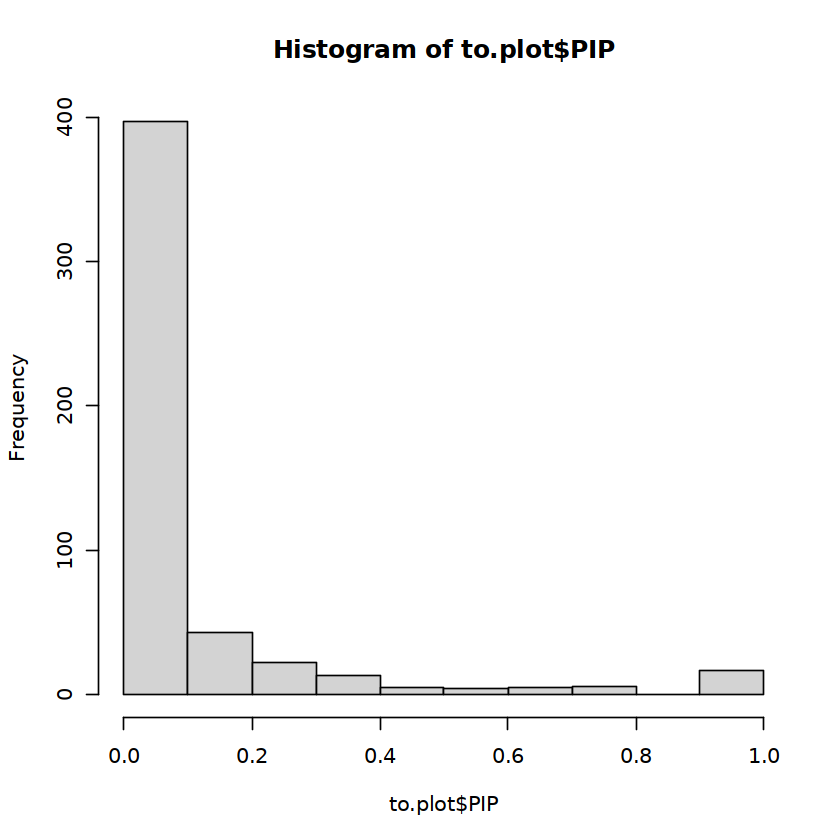

In [29]:
hist(to.plot$PIP)

pdf 
  2

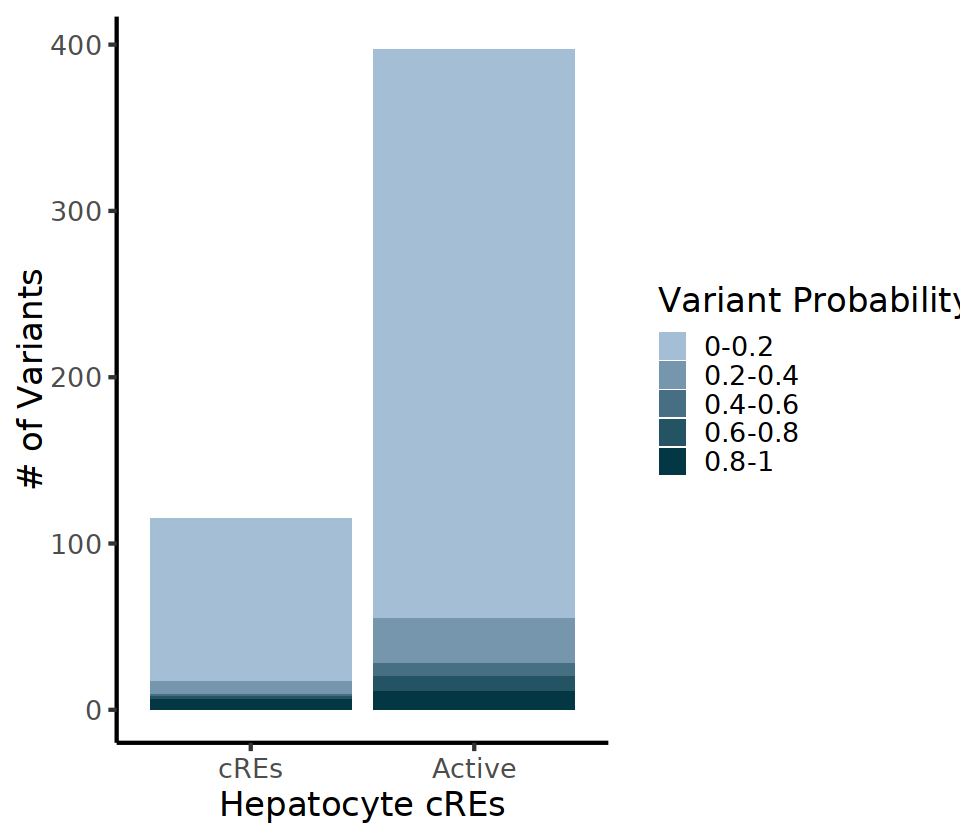

In [56]:
options(repr.plot.width=8)
p1 <- ggplot(to.plot, aes(x=type, fill=pip.bin)) + 
    geom_bar() + 
    scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(to.plot$pip.bin)))) +
    theme_classic(base_size=20) + xlab("Hepatocyte cREs") + ylab('# of Variants') + labs(fill='Variant Probability')

p1

pdf(file = '/nfs/lab/welison/Liver/Plots/250124_WE_Hep_cREs_active_Finemapping_Variants.pdf', width=8)
p1
dev.off()

pdf 
  2

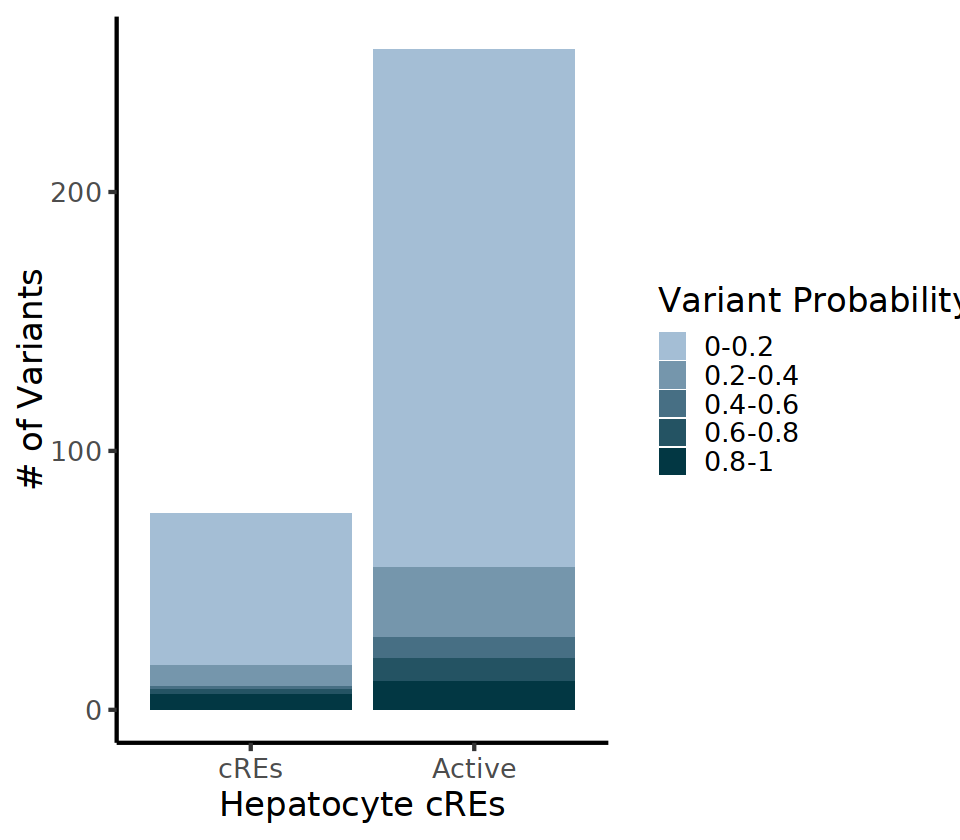

In [57]:
p1 <- ggplot(filter(to.plot, PIP >0.01), aes(x=type, fill=pip.bin)) + 
    geom_bar() + 
    scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(to.plot$pip.bin)))) +
    theme_classic(base_size=20) + xlab("Hepatocyte cREs") + ylab('# of Variants') + labs(fill='Variant Probability')

p1

pdf(file = '/nfs/lab/welison/Liver/Plots/250124_WE_Hep_cREs_active_Finemapping_Variants_0.01_PIP.pdf')
p1
dev.off()

In [46]:
to.plot %>%
    select(LEAD.SNP, type, PIP) %>%
    group_by(LEAD.SNP, type) %>%
    summarise(PIP=sum(PIP))

`summarise()` has grouped output by 'LEAD.SNP'. You can override using the `.groups` argument.


LEAD.SNP,type,PIP
<chr>,<fct>,<dbl>
rs10433937,Active,0.1116
rs10774625,cREs,0.0736
rs10774625,Active,0.5644
rs10883451,Active,0.9994
rs115038698,cREs,0.5627
rs115038698,Active,0.0205
rs11621792,cREs,0.9494
rs11621792,Active,0.9850
rs11668950,cREs,0.0079


`summarise()` has grouped output by 'LEAD.SNP'. You can override using the `.groups` argument.


pdf 
  2

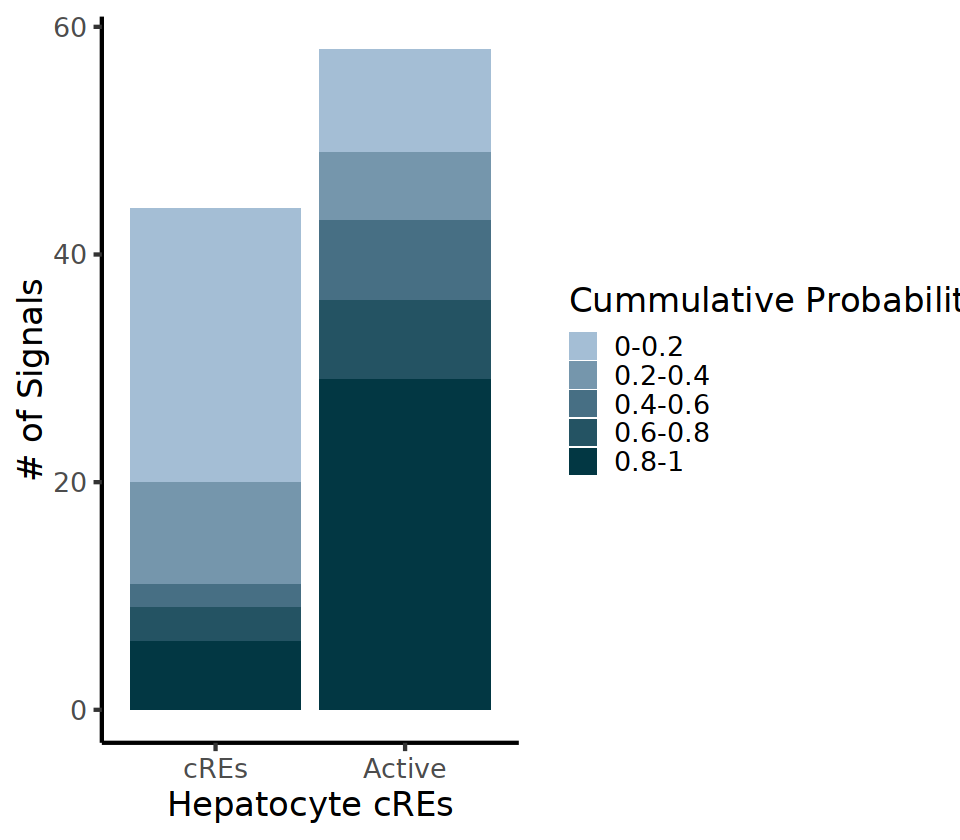

In [58]:
p1 <- to.plot %>% #filter(to.plot, PIP >0.01) %>%
    select(LEAD.SNP, type, PIP) %>%
    group_by(LEAD.SNP, type) %>%
    summarise(PIP=sum(PIP)) %>%
    mutate(pip.bin=ifelse(PIP < 0.2, '0-0.2',
                    ifelse(PIP < 0.4, '0.2-0.4',
                    ifelse(PIP < 0.6, '0.4-0.6',
                    ifelse(PIP < 0.8, '0.6-0.8','0.8-1'))))) %>%
    #mutate(color='same') %>%
    ggplot(aes(x=type, fill=pip.bin)) + 
    geom_bar() + 
    scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(to.plot$pip.bin)))) +
    theme_classic(base_size=20) + xlab("Hepatocyte cREs") + ylab('# of Signals') + labs(fill='Cummulative Probability')

p1

pdf(file = '/nfs/lab/welison/Liver/Plots/250124_WE_Hep_cREs_active_Finemapping_Signals_0.01_PIP.pdf')
p1
dev.off()

In [59]:
dev.off()

null device 
          1